In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score, classification_report

# 1. Load Data
data_path = '../data/student-mat.csv'
df = pd.read_csv(data_path, sep=';')

# 2. Separate Features (X) and Continuous Target (y)
X = df.drop(columns=['G3'])
y = df['G3']

# 3. Define Preprocessing Pipeline
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
    ]
)

# 4. Train-Test Split (80% Train, 20% Test) using fixed seed
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Data successfully split:")
print(f"Training samples: {X_train.shape[0]} students")
print(f"Testing samples:  {X_test.shape[0]} students")

Data successfully split:
Training samples: 316 students
Testing samples:  79 students


In [2]:
# Stage 1: Formulate Binary Hurdle Target (0 = zero/absence, 1 = sat exam)
z_train = (y_train > 0).astype(int)
z_test = (y_test > 0).astype(int)

# Fit Stage 1 Classifier (Random Forest Classifier)
hurdle_clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42))
])
hurdle_clf.fit(X_train, z_train)
z_pred = hurdle_clf.predict(X_test)

print("--- Stage 1: Exam Attendance / Zero Hurdle Classification ---")
print(f"Classification Accuracy: {accuracy_score(z_test, z_pred):.4f}")
print(classification_report(z_test, z_pred, target_names=['Zero Mark (Absence)', 'Present (>0)']))

# Stage 2: Fit Regressor Strictly on Students Who Sat the Exam (y > 0)
mask_train = (y_train > 0)
X_train_present = X_train[mask_train]
y_train_present = y_train[mask_train]

hurdle_reg = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, max_depth=6, random_state=42))
])
hurdle_reg.fit(X_train_present, y_train_present)

# Combined Hurdle Prediction
y_pred_hurdle = np.zeros_like(y_test, dtype=float)
# Predict continuous marks only for students classified as 'Present'
present_indices = np.where(z_pred == 1)[0]
if len(present_indices) > 0:
    y_pred_hurdle[present_indices] = hurdle_reg.predict(X_test.iloc[present_indices])

# Evaluate Two-Stage Model
rmse_hurdle = np.sqrt(mean_squared_error(y_test, y_pred_hurdle))
mae_hurdle = mean_absolute_error(y_test, y_pred_hurdle)
r2_hurdle = r2_score(y_test, y_pred_hurdle)

print("\n--- Two-Stage Hurdle Model Overall Performance ---")
print(f"RMSE:     {rmse_hurdle:.3f}")
print(f"MAE:      {mae_hurdle:.3f}")
print(f"R^2 Score: {r2_hurdle:.3f}")

--- Stage 1: Exam Attendance / Zero Hurdle Classification ---
Classification Accuracy: 0.9494
                     precision    recall  f1-score   support

Zero Mark (Absence)       1.00      0.20      0.33         5
       Present (>0)       0.95      1.00      0.97        74

           accuracy                           0.95        79
          macro avg       0.97      0.60      0.65        79
       weighted avg       0.95      0.95      0.93        79


--- Two-Stage Hurdle Model Overall Performance ---
RMSE:     2.097
MAE:      1.141
R^2 Score: 0.786


--- Advanced Architecture Comparison ---


/Users/jaskirat_singh_grewal/Documents/IDC409_Project/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/jaskirat_singh_grewal/Documents/IDC409_Project/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/jaskirat_singh_grewal/Documents/IDC409_Project/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/jaskirat_singh_grewal/Documents/IDC409_Project/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/jaskirat_singh_grewal/Documents/IDC409_Project/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/jaskirat_singh_grewal/Documents/IDC409_Project/.venv/lib/python3.9/site-packages/

,Model,RMSE,MAE,R^2 Score
0,Standard Random Forest Baseline,1.958,1.189,0.813
1,Two-Stage Hurdle (RF + RF),2.097,1.141,0.786
2,Feedforward Neural Network (MLP),2.654,2.043,0.656


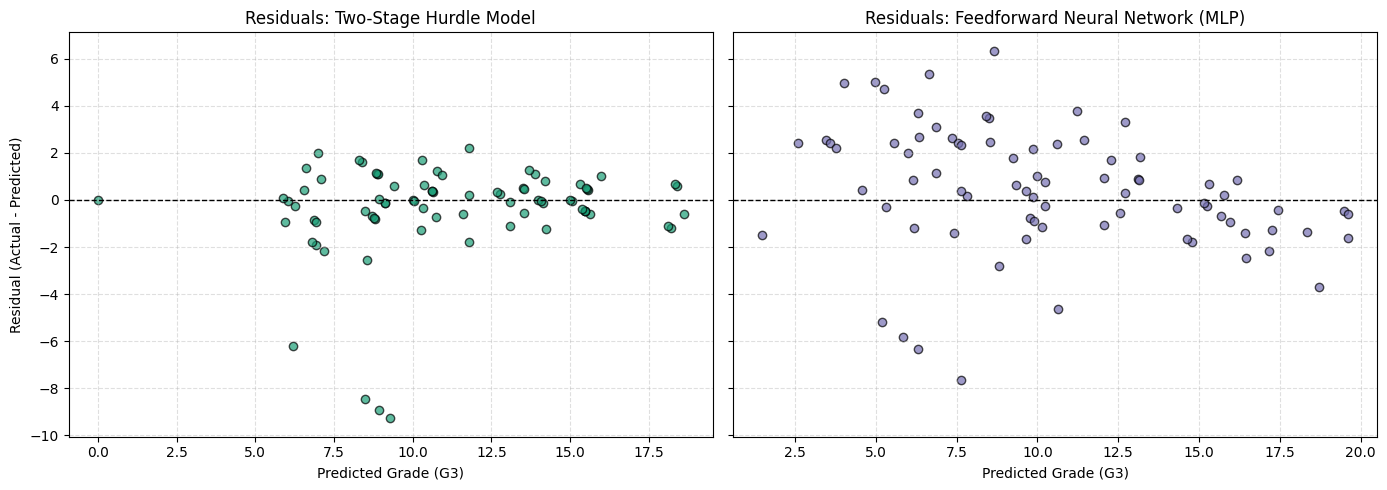

In [3]:
# 1. Construct Compact Feedforward Neural Network Pipeline
# Hidden layers: 32 -> 16, ReLU activation, L2 regularization alpha=0.05
mlp_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('mlp', MLPRegressor(
        hidden_layer_sizes=(32, 16),
        activation='relu',
        solver='adam',
        alpha=0.05,
        max_iter=1000,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.15
    ))
])

mlp_pipeline.fit(X_train, y_train)
y_pred_mlp = mlp_pipeline.predict(X_test)

rmse_mlp = np.sqrt(mean_squared_error(y_test, y_pred_mlp))
mae_mlp = mean_absolute_error(y_test, y_pred_mlp)
r2_mlp = r2_score(y_test, y_pred_mlp)

# 2. Performance Comparison Table
advanced_results = pd.DataFrame([
    {"Model": "Standard Random Forest Baseline", "RMSE": 1.958, "MAE": 1.189, "R^2 Score": 0.813},
    {"Model": "Two-Stage Hurdle (RF + RF)", "RMSE": round(rmse_hurdle, 3), "MAE": round(mae_hurdle, 3), "R^2 Score": round(r2_hurdle, 3)},
    {"Model": "Feedforward Neural Network (MLP)", "RMSE": round(rmse_mlp, 3), "MAE": round(mae_mlp, 3), "R^2 Score": round(r2_mlp, 3)}
])

print("--- Advanced Architecture Comparison ---")
display(advanced_results)

# 3. Residual Diagnostics Plot Comparison
residuals_hurdle = y_test - y_pred_hurdle
residuals_mlp = y_test - y_pred_mlp

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Hurdle Residuals
axes[0].scatter(y_pred_hurdle, residuals_hurdle, color='#1b9e77', edgecolor='black', alpha=0.7)
axes[0].axhline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_title("Residuals: Two-Stage Hurdle Model")
axes[0].set_xlabel("Predicted Grade (G3)")
axes[0].set_ylabel("Residual (Actual - Predicted)")
axes[0].grid(True, linestyle='--', alpha=0.4)

# MLP Residuals
axes[1].scatter(y_pred_mlp, residuals_mlp, color='#7570b3', edgecolor='black', alpha=0.7)
axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title("Residuals: Feedforward Neural Network (MLP)")
axes[1].set_xlabel("Predicted Grade (G3)")
axes[1].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('../images/advanced_models_residuals.png', dpi=300)
plt.show()